# Notebook 03 — Word2Vec: Representaciones Estáticas
**Proyecto 2 | Análisis Semántico de Letras Musicales**  
**Curso:** Minería de Textos — CUC  

---
## Objetivo
Entrenar modelos Word2Vec (CBOW y Skip-Gram) sobre el corpus musical,
explorar campos semánticos por género, realizar analogías vectoriales
y calcular similitud coseno entre géneros.


## 0. Dependencias

In [1]:
!pip install -q gensim scikit-learn matplotlib seaborn numpy pandas pymongo python-dotenv
print("Dependencias listas")

Dependencias listas



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Cargar corpus desde MongoDB

In [2]:
import sys
sys.path.append("..")

from src.database.MongoConnection import MongoConnection
from src.entities.consultar_base_datos import consultar_base_datos

cargador = consultar_base_datos()
cargador.cargar_por_generos(["pop","alternative pop","hip hop","alternative rock","dance pop", "rock"])
df = cargador.df

print(f"Canciones cargadas: {len(df):,}")
print(f"Géneros disponibles: {df['genero'].unique()}")
print(f"Idiomas: {df['idioma'].value_counts().to_dict()}")
df.head(3)

Conectado a MongoDB Atlas: analisisMusical
Canciones cargadas: 5,955
Géneros disponibles: <StringArray>
['pop', 'alternative pop', 'hip hop', 'alternative rock', 'dance pop', 'rock']
Length: 6, dtype: str
Idiomas: {'en': 5827, 'es': 67, 'fr': 7, 'so': 6, 'cy': 6, 'tl': 5, 'id': 5, 'af': 5, 'tr': 4, 'no': 3, 'de': 3, 'pt': 3, 'el': 2, 'nl': 1, 'hu': 1, 'cs': 1, 'fa': 1, 'ru': 1, 'sq': 1, 'sl': 1, 'da': 1, 'sk': 1, 'pl': 1, 'sw': 1, 'it': 1}


,id,titulo,artista,genero,anio,letra,idioma,fuente,url_fuente,fecha_recopilacion,metricas_num_palabras,metricas_densidad_lexica,metricas_ratio_sust_verbos,pos_tags_nltk,pos_tags_spacy,embeddings_word2vec_avg,embeddings_beto_cls
0,69c39f3480581b88ccabedc8,"​thank u, next",Ariana Grande,pop,2018,thought i'd end up with sean but he wasn't a m...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,463,0.3045,1.0814,"[[[thought, NN], ['d, MD], [end, VB], [sean, J...","[[thought, NOUN], [end, PROPN], [sean, PROPN],...","[0.13370610773563385, 0.20094473659992218, 0.0...",[]
1,69c39f3480581b88ccabedc9,7 rings,Ariana Grande,pop,2019,yeah breakfast at tiffany's and bottles of bub...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,490,0.3776,1.5147,"[[[yeah, NN], [breakfast, NN], [tiffany, NN], ...","[[yeah, INTJ], [breakfast, NOUN], [tiffany, NO...","[0.2434837520122528, 0.18959365785121918, 0.14...",[]
2,69c39f3480581b88ccabedca,​God is a woman,Ariana Grande,pop,2018,you you love it how i move you you love it how...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,439,0.2415,1.4792,"[[[love, VBP], [move, VBP], [love, VBP], [touc...","[[love, NOUN], [love, NOUN], [touch, NOUN], [s...","[0.18451783061027527, 0.19660046696662903, 0.1...",[]


Canciones cargadas: 5,955
Géneros disponibles: <StringArray>
['pop', 'alternative pop', 'hip hop', 'alternative rock', 'dance pop', 'rock']
Length: 6, dtype: str
Idiomas: {'en': 5827, 'es': 67, 'fr': 7, 'so': 6, 'cy': 6, 'tl': 5, 'id': 5, 'af': 5, 'tr': 4, 'no': 3, 'de': 3, 'pt': 3, 'el': 2, 'nl': 1, 'hu': 1, 'cs': 1, 'fa': 1, 'ru': 1, 'sq': 1, 'sl': 1, 'da': 1, 'sk': 1, 'pl': 1, 'sw': 1, 'it': 1}


,id,titulo,artista,genero,anio,letra,idioma,fuente,url_fuente,fecha_recopilacion,metricas_num_palabras,metricas_densidad_lexica,metricas_ratio_sust_verbos,pos_tags_nltk,pos_tags_spacy,embeddings_word2vec_avg,embeddings_beto_cls
0,69c39f3480581b88ccabedc8,"​thank u, next",Ariana Grande,pop,2018,thought i'd end up with sean but he wasn't a m...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,463,0.3045,1.0814,"[[[thought, NN], ['d, MD], [end, VB], [sean, J...","[[thought, NOUN], [end, PROPN], [sean, PROPN],...","[0.13370610773563385, 0.20094473659992218, 0.0...",[]
1,69c39f3480581b88ccabedc9,7 rings,Ariana Grande,pop,2019,yeah breakfast at tiffany's and bottles of bub...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,490,0.3776,1.5147,"[[[yeah, NN], [breakfast, NN], [tiffany, NN], ...","[[yeah, INTJ], [breakfast, NOUN], [tiffany, NO...","[0.2434837520122528, 0.18959365785121918, 0.14...",[]
2,69c39f3480581b88ccabedca,​God is a woman,Ariana Grande,pop,2018,you you love it how i move you you love it how...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,439,0.2415,1.4792,"[[[love, VBP], [move, VBP], [love, VBP], [touc...","[[love, NOUN], [love, NOUN], [touch, NOUN], [s...","[0.18451783061027527, 0.19660046696662903, 0.1...",[]


## 2. Entrenar modelos Word2Vec (CBOW y Skip-Gram)

In [3]:
from src.embeddings.embeddings_w2v import EntrenadorWord2Vec

entrenador = EntrenadorWord2Vec(df, col_letra="letra")

# Entrenar ambos modelos con los mismos hiperparámetros para comparación justa
entrenador.entrenar(
    vector_size=100,   # dimensión del vector
    window=5,          # ventana de contexto
    min_count=2,       # ignorar palabras con frecuencia < 2
    epochs=10
)

# Persistir en disco para no re-entrenar
entrenador.guardar("../data/results")

Corpus preparado: 5,955 canciones | 2,375,440 tokens totales

Entrenando CBOW...
  Vocabulario: 24,689 palabras
  Dimensión:   100d

Entrenando Skip-Gram...
  Vocabulario: 24,689 palabras
  Dimensión:   100d

Ambos modelos entrenados.
CBOW guardado en: ../data/results/w2v_cbow.model
Skip-Gram guardado en: ../data/results/w2v_skipgram.model


## 3. Exploración de campos semánticos por género

Usamos `most_similar()` para descubrir los clusters temáticos dominantes
(amor, fiesta, protesta, violencia, naturaleza) en cada género.


In [4]:
from src.embeddings.embeddings_w2v import AnalizadorWord2Vec

analizador_sg   = AnalizadorWord2Vec(entrenador.modelo_sg)
analizador_cbow = AnalizadorWord2Vec(entrenador.modelo_cbow)

# Palabras clave representativas de letras musicales
PALABRAS_CLAVE = ["love", "night", "heart", "feel", "life", "know", "time", "baby"]

print("=" * 60)
print("Vecinos semánticos — Skip-Gram")
print("=" * 60)
for palabra in PALABRAS_CLAVE:
    analizador_sg.palabras_similares(palabra, topn=8)

Vecinos semánticos — Skip-Gram

Palabras más similares a 'love':
  loveee               0.7284
  looove               0.6899
  youuuuuu             0.6563
  lovе                 0.6525
  jstatus              0.6507
  waaant               0.6309
  solitude             0.6063
  mumumust             0.6029

Palabras más similares a 'night':
  danced               0.6602
  reward               0.6584
  underdogs            0.6582
  twentyyear           0.6563
  0year                0.6461
  day                  0.6329
  mamamamarry          0.6243
  premiere             0.6109

Palabras más similares a 'heart':
  skips                0.6475
  beating              0.6283
  brea                 0.6057
  pulses               0.5998
  aaate                0.5998
  emily                0.5951
  opium                0.5936
  goddamnit            0.5916

Palabras más similares a 'feel':
  itwhy                0.6054
  unwind               0.5937
  elope                0.5774
  shakes             

In [5]:
# Entrenar un modelo por género y comparar vecinos semánticos
resultados_genero = analizador_sg.campos_semanticos_por_genero(
    df,
    col_letra="letra",
    col_genero="genero",
    palabras_clave=["love", "night", "feel", "life"],
    topn=8
)

Corpus preparado: 3,350 canciones | 1,165,823 tokens totales

── pop (3350 canciones) ──
  love         → ['hate', 'me', 'want', 'that', 'you']
  night        → ['day', 'friday', 'sleep', 'time', 'cigerette']
  feel         → ['whine', 'touch', 'feels', 'feeling', 'move']
  life         → ['world', 'live', 'living', 'for', 'hope']
Corpus preparado: 157 canciones | 33,261 tokens totales

── alternative pop (157 canciones) ──
  love         → ['future', 'mymy', 'fake', 'doesn', 'meets']
  night        → ['born', 'seem', 'coke', 'life', 'called']
  feel         → ['better', 'already', 'glad', 'just', 'yeah']
  life         → ['words', 'black', 'times', 'called', 'wrong']
Corpus preparado: 1,910 canciones | 1,039,265 tokens totales

── hip hop (1910 canciones) ──
  love         → ['hate', 'lie', 'true', 'help', 'savannah']
  night        → ['day', 'ends', 'weekend', 'morning', 'late']
  feel         → ['feels', 'feeling', 'sometimes', 'treat', 'sound']
  life         → ['world', 'living', 

## 4. Analogías vectoriales

In [6]:
print("=" * 60)
print("Analogías vectoriales — Skip-Gram")
print("=" * 60)

# Analogías generales
print("\n--- Dominio general ---")
analizador_sg.analogia("woman", "king", "man")         # rey - hombre + mujer
analizador_sg.analogia("paris", "france", "berlin")    # france - paris + berlin

# Analogías dentro del dominio musical
print("\n--- Dominio musical ---")
analizador_sg.analogia("sad",    "cry",   "happy")
analizador_sg.analogia("dark",   "night", "day")
analizador_sg.analogia("guitar", "rock",  "piano")
analizador_sg.analogia("dance",  "party", "sleep")

# Documentar resultados: ¿cuáles funcionan? ¿cuáles no?
print("\nNota: Los resultados dependen del corpus de entrenamiento.")
print("Analogías con vocabulario muy frecuente en letras tienden a funcionar mejor.")

Analogías vectoriales — Skip-Gram

--- Dominio general ---

Analogía: king - man + woman ≈
  kong                 0.5138
  bassjackers          0.4585
  ten                  0.4451
  trace                0.4137
  queenie              0.4028

Analogía: france - berlin + paris ≈
  homecoming           0.4672
  suite                0.4409
  brrrt                0.4222
  clarence             0.4214
  abu                  0.4187

--- Dominio musical ---

Analogía: cry - happy + sad ≈
  serenade             0.5136
  sometime             0.4710
  weezyana             0.4674
  riverer              0.4498
  glamour              0.4426

Analogía: night - day + dark ≈
  wewewewe             0.5978
  wewe                 0.5741
  darkdarkdarkdark     0.5719
  underdogs            0.5629
  oooooooooo           0.5601

Analogía: rock - piano + guitar ≈
  getty                0.5443
  possessive           0.5216
  choker               0.5172
  fraggle              0.5164
  stylin               0.4891

In [7]:
# Comparar CBOW vs Skip-Gram en la misma analogía
print("=== CBOW vs Skip-Gram ===")
for pos1, pos2, neg in [("woman","king","man"), ("sad","cry","happy"), ("dark","night","day")]:
    print(f"\nAnalogía: {pos2} - {neg} + {pos1}")
    print("  SKIP-GRAM:")
    analizador_sg.analogia(pos1, pos2, neg, topn=3)
    print("  CBOW:")
    analizador_cbow.analogia(pos1, pos2, neg, topn=3)

=== CBOW vs Skip-Gram ===

Analogía: king - man + woman
  SKIP-GRAM:

Analogía: king - man + woman ≈
  kong                 0.5138
  bassjackers          0.4585
  ten                  0.4451
  CBOW:

Analogía: king - man + woman ≈
  kong                 0.4327
  trace                0.4268
  veil                 0.4201

Analogía: cry - happy + sad
  SKIP-GRAM:

Analogía: cry - happy + sad ≈
  serenade             0.5136
  sometime             0.4710
  weezyana             0.4674
  CBOW:

Analogía: cry - happy + sad ≈
  laugh                0.4479
  riverer              0.3779
  loud                 0.3668

Analogía: night - day + dark
  SKIP-GRAM:

Analogía: night - day + dark ≈
  wewewewe             0.5978
  wewe                 0.5741
  darkdarkdarkdark     0.5719
  CBOW:

Analogía: night - day + dark ≈
  dancing              0.5804
  moonlight            0.5322
  moon                 0.4778


## 5. Similitud coseno entre géneros


Similitud coseno entre géneros:
                     pop  alternative pop  hip hop  alternative rock  dance pop    rock
pop               1.0000           0.9938   0.9878            0.9946     0.9978  0.9881
alternative pop   0.9938           1.0000   0.9836            0.9911     0.9919  0.9818
hip hop           0.9878           0.9836   1.0000            0.9795     0.9836  0.9864
alternative rock  0.9946           0.9911   0.9795            1.0000     0.9913  0.9892
dance pop         0.9978           0.9919   0.9836            0.9913     1.0000  0.9826
rock              0.9881           0.9818   0.9864            0.9892     0.9826  1.0000


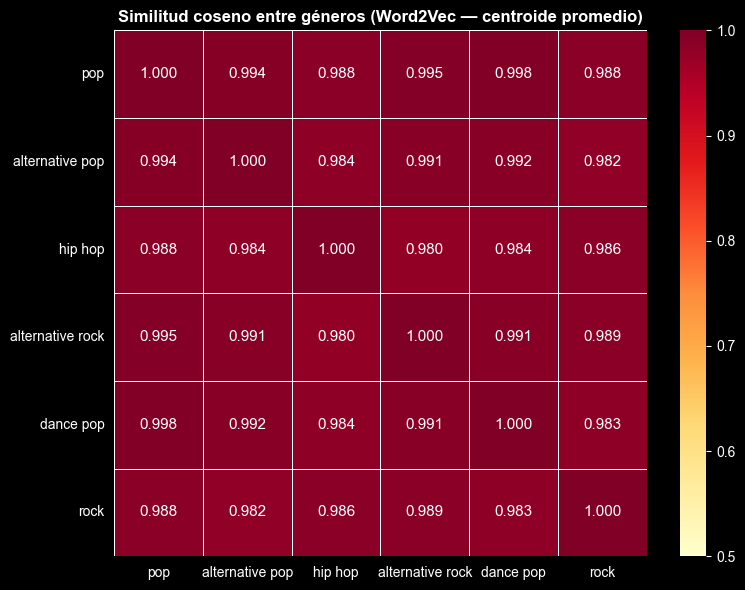


Pares de géneros más similares:
pop               dance pop           0.997829
                  alternative rock    0.994564
                  alternative pop     0.993766
alternative pop   dance pop           0.991861
alternative rock  dance pop           0.991307
alternative pop   alternative rock    0.991104


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df_sim = analizador_sg.similitud_entre_generos(
    df, col_letra="letra", col_genero="genero"
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_sim, annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
    annot_kws={"size": 11}
)
ax.set_title("Similitud coseno entre géneros (Word2Vec — centroide promedio)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPares de géneros más similares:")
sim_upper = df_sim.where(
    __import__("numpy").triu(__import__("numpy").ones(df_sim.shape, dtype=bool), k=1)
).stack().sort_values(ascending=False)
print(sim_upper.head(6).to_string())

## 6. Vocabulario exclusivo por género

In [9]:
import pandas as pd

exclusivo = analizador_sg.vocabulario_exclusivo(
    df, col_letra="letra", col_genero="genero", top_n=15
)

# Mostrar como tabla
max_len = max(len(v) for v in exclusivo.values())
tabla = {}
for genero, palabras in exclusivo.items():
    tabla[genero] = palabras + [""] * (max_len - len(palabras))

df_excl = pd.DataFrame(tabla)
df_excl.index = [f"#{i+1}" for i in range(max_len)]
print("\nPalabras más características por género (exclusividad relativa):")
print(df_excl.to_string())


Vocabulario exclusivo de 'pop':
  ['uishi', 'kalẹ', 'kwa', 'mababu', 'baik', 'mawingu', 'katika', 'sibirobo', 'olúwa', 'robi', 'sọ', 'tidak', 'bisa', 'melihat', 'mrefu']

Vocabulario exclusivo de 'alternative pop':
  ['onun', 'sen', 'artık', 'olmak', 'gerekse', 'vaat', 'olsaydı', 'göz', 'bir', 'şeyi', 'bozar', 'bildiğin', 'söyle', 'yüzme', 'seni']

Vocabulario exclusivo de 'hip hop':
  ['tatort', 'vom', 'ئێستا', 'bozar', 'ئەگەر', 'goatgreatest', 'lelket', 'eğer', 'میگمکی', 'دا', 'کە', 'artık', 'sen', 'ئەمە', 'چونکە']

Vocabulario exclusivo de 'alternative rock':
  ['nke', 'nile', 'أبي', 'ihi', 'ihe', 'در', 'ekwu', 'chukwu', 'قادر', 'يا', 'sol', 'gini', 'feliz', 'del', 'muy']

Vocabulario exclusivo de 'dance pop':
  ['sur', 'muy', 'tiempo', 'calor', 'ciega', 'cielo', 'eras', 'des', 'caliente', 'copa', 'vino', 'infierno', 'tes', 'placer', 'del']

Vocabulario exclusivo de 'rock':
  ['cans', 'meanness', '88', 'states', 'hallways', 'scotland', 'corners', 'sharks', 'reservoir', 'soakin', 'c

## 7. Visualización t-SNE de embeddings de palabras

Canciones en inglés: 5,827 de 5,955 totales
Vocabulario del modelo (inglés): 24,689 palabras


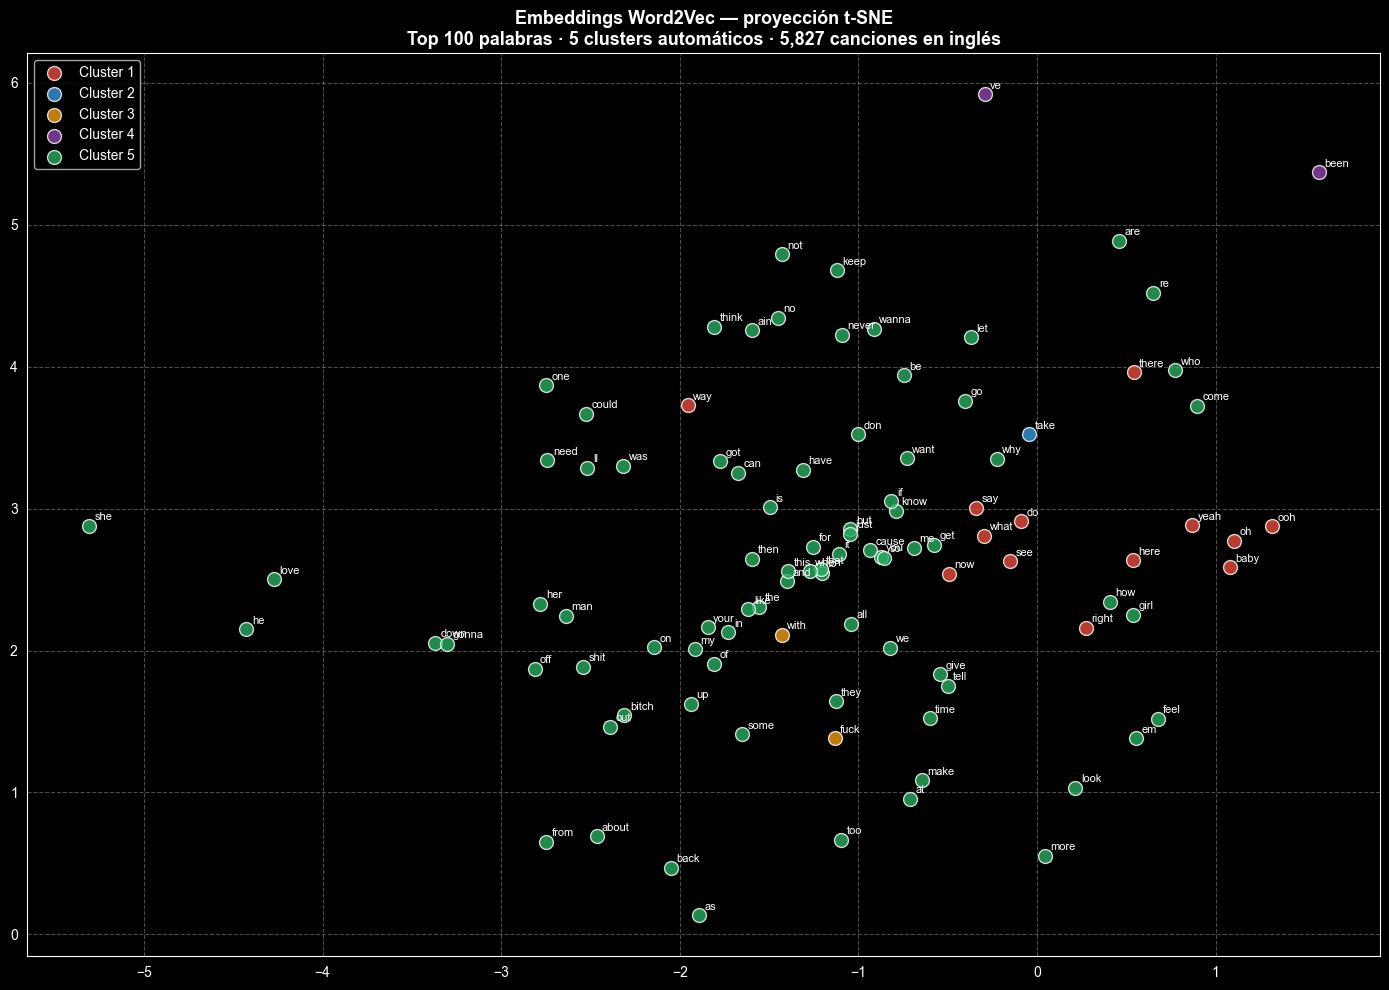

In [11]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import numpy as np
from src.embeddings.embeddings_w2v import EntrenadorWord2Vec
# ── 1. Filtrar corpus a canciones en inglés ──────────────────────────────────
df_en = df[df["idioma"].str.lower() == "en"].copy()
print(f"Canciones en inglés: {len(df_en):,} de {len(df):,} totales")

# ── 2. Entrenar modelo solo con corpus en inglés ─────────────────────────────
wv = entrenador.modelo_sg.wv
print(f"Vocabulario del modelo (inglés): {len(wv):,} palabras")

# ── 3. Tomar las N palabras más frecuentes del corpus real ───────────────────
TOP_N_PALABRAS = 100   # palabras más frecuentes a visualizar
N_CLUSTERS     = 5     # grupos semánticos a descubrir

# wv.index_to_key devuelve palabras ordenadas por frecuencia descendente
palabras_top = [
    p for p in wv.index_to_key[:TOP_N_PALABRAS]
    if p.isalpha()          # descartar tokens numéricos o con símbolos
]

vectores_top = np.array([wv[p] for p in palabras_top])

# ── 4. Agrupar automáticamente con KMeans ────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
etiquetas = kmeans.fit_predict(vectores_top)

# Paleta de colores para los clusters
paleta = ["#e74c3c", "#3498db", "#f39c12", "#8e44ad", "#27ae60"]
colores_cluster = {i: paleta[i] for i in range(N_CLUSTERS)}

# ── 5. t-SNE y visualización ──────────────────────────────────────────────────
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(palabras_top) - 1)
)
v2d = tsne.fit_transform(vectores_top)

fig, ax = plt.subplots(figsize=(14, 10))
for cluster_id in range(N_CLUSTERS):
    idx = [i for i, e in enumerate(etiquetas) if e == cluster_id]
    ax.scatter(
        v2d[idx, 0], v2d[idx, 1],
        c=colores_cluster[cluster_id],
        label=f"Cluster {cluster_id + 1}",
        s=100, alpha=0.80, edgecolors="white", linewidth=1.0
    )
    for i in idx:
        ax.annotate(
            palabras_top[i], (v2d[i, 0], v2d[i, 1]),
            fontsize=8, xytext=(4, 4), textcoords="offset points"
        )

ax.set_title(
    f"Embeddings Word2Vec — proyección t-SNE\n"
    f"Top {len(palabras_top)} palabras · {N_CLUSTERS} clusters automáticos · "
    f"{len(df_en):,} canciones en inglés",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


## 8. Embeddings de canciones completas (vector promedio)

In [12]:
from src.embeddings.embeddings_w2v import calcular_vector_promedio
import numpy as np

# Calcular vector promedio para cada canción
print("Calculando vectores promedio word2vec para cada canción...")
vectores_canciones = []
wv = entrenador.modelo_sg.wv

for letra in df["letra"].fillna(""):
    vec = calcular_vector_promedio(str(letra), wv)
    vectores_canciones.append(vec if vec else [0.0] * 100)

vectores_array = np.array(vectores_canciones)
print(f"Matriz de embeddings: {vectores_array.shape}")
print(f"  {vectores_array.shape[0]} canciones × {vectores_array.shape[1]} dimensiones")

Calculando vectores promedio word2vec para cada canción...
Matriz de embeddings: (5955, 100)
  5955 canciones × 100 dimensiones


## 9. Actualizar embeddings en MongoDB

In [13]:
from src.embeddings.embeddings_w2v import actualizar_embeddings_mongodb

# Actualiza embeddings.word2vec_avg en cada documento de MongoDB
actualizar_embeddings_mongodb(
    df=df,
    modelo=entrenador.modelo_sg,
    col_id="id",
    col_letra="letra",
    batch_size=100,
)
print("word2vec_avg actualizado correctamente en MongoDB.")

  Actualizados: 100/6940
  Actualizados: 200/6940
  Actualizados: 300/6940
  Actualizados: 400/6940
  Actualizados: 500/6940
  Actualizados: 600/6940
  Actualizados: 700/6940
  Actualizados: 800/6940
  Actualizados: 900/6940
  Actualizados: 1000/6940
  Actualizados: 1100/6940
  Actualizados: 1200/6940
  Actualizados: 1300/6940
  Actualizados: 1400/6940
  Actualizados: 1500/6940
  Actualizados: 1600/6940
  Actualizados: 1700/6940
  Actualizados: 1800/6940
  Actualizados: 1900/6940
  Actualizados: 2000/6940
  Actualizados: 2100/6940
  Actualizados: 2200/6940
  Actualizados: 2300/6940
  Actualizados: 2400/6940
  Actualizados: 2500/6940
  Actualizados: 2600/6940
  Actualizados: 2700/6940
  Actualizados: 2800/6940
  Actualizados: 2900/6940
  Actualizados: 3000/6940
  Actualizados: 3100/6940
  Actualizados: 3200/6940
  Actualizados: 3300/6940
  Actualizados: 3400/6940
  Actualizados: 3500/6940
  Actualizados: 3600/6940
  Actualizados: 3700/6940
  Actualizados: 3800/6940
  Actualizados: 3900/